<a href="https://colab.research.google.com/github/jeeva477/NLP/blob/main/NLP_PROJECT_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
sports = [
    "India defeated Australia in the cricket world cup.",
    "Virat Kohli scored a brilliant century.",
    "The football team won the championship.",
    "The Olympic games begin next month.",
    "The tennis player reached the finals.",
    "The basketball team celebrated their victory.",
    "The badminton tournament attracted many fans.",
    "The captain scored the winning goal.",
    "The coach announced the final squad.",
    "The athlete won a gold medal."
]

politics = [
    "The parliament passed a new education bill.",
    "The prime minister addressed the nation.",
    "The government announced a tax policy.",
    "Election campaigns started across the country.",
    "The president met foreign leaders.",
    "The cabinet approved the proposal.",
    "The minister launched a welfare scheme.",
    "The senate discussed economic reforms.",
    "The opposition criticized the decision.",
    "The election results were announced."
]

technology = [
    "Artificial intelligence is changing healthcare.",
    "Google launched a new AI model.",
    "Python is popular for machine learning.",
    "Cybersecurity threats are increasing.",
    "Apple released a new smartphone.",
    "Cloud computing improves business efficiency.",
    "The startup developed a smart robot.",
    "Machine learning predicts customer behaviour.",
    "The software update improved performance.",
    "Researchers built a quantum computer."
]

entertainment = [
    "The new movie broke box office records.",
    "The actor won the best actor award.",
    "Fans enjoyed the music concert.",
    "The film trailer became viral.",
    "The actress attended the award ceremony.",
    "The singer released a new album.",
    "The comedy show received positive reviews.",
    "The director announced a sequel.",
    "The web series became a hit.",
    "The audience applauded the performance."
]

business = [
    "Stock markets closed higher today.",
    "The company reported huge profits.",
    "The startup raised investment funding.",
    "Investors purchased company shares.",
    "The bank reduced interest rates.",
    "The economy showed positive growth.",
    "The finance minister presented the budget.",
    "The company expanded its business.",
    "The CEO announced a merger.",
    "Retail sales increased this quarter."
]


In [20]:
data = []

for article in sports:
    data.append(["Sports", article])

for article in politics:
    data.append(["Politics", article])

for article in technology:
    data.append(["Technology", article])

for article in entertainment:
    data.append(["Entertainment", article])

for article in business:
    data.append(["Business", article])

df = pd.DataFrame(data, columns=["Category", "Article"])

print(df.head())

  Category                                            Article
0   Sports  India defeated Australia in the cricket world ...
1   Sports            Virat Kohli scored a brilliant century.
2   Sports            The football team won the championship.
3   Sports                The Olympic games begin next month.
4   Sports              The tennis player reached the finals.


In [22]:
nltk.download("punkt_tab")
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Text"] = df["Article"].apply(preprocess)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [23]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Clean_Text"])
y = df["Category"]

# ------------------------------
# Train-Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [24]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [25]:
y_pred = model.predict(X_test)

In [26]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.4

Classification Report

               precision    recall  f1-score   support

     Business       0.50      0.50      0.50         2
Entertainment       0.00      0.00      0.00         2
     Politics       0.50      0.50      0.50         2
       Sports       0.50      0.50      0.50         2
   Technology       1.00      0.50      0.67         2

     accuracy                           0.40        10
    macro avg       0.50      0.40      0.43        10
 weighted avg       0.50      0.40      0.43        10



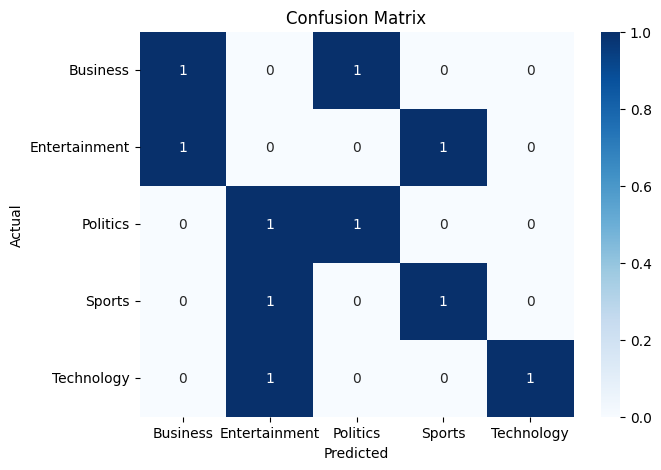

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [28]:
news = [
    "Apple launched a powerful AI smartphone with advanced processor."
]

news_clean = [preprocess(x) for x in news]

news_vector = vectorizer.transform(news_clean)

prediction = model.predict(news_vector)

print("\nPredicted Category:", prediction[0])



Predicted Category: Technology


In [29]:
news2 = [
    "India defeated England in the cricket final."
]

news2_clean = [preprocess(x) for x in news2]

news2_vector = vectorizer.transform(news2_clean)

prediction2 = model.predict(news2_vector)

print("Predicted Category:", prediction2[0])

Predicted Category: Sports
